In [1]:
!pip install kaggle

In [2]:
# configuring the path of Kaggle.json file
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d utkarshsaxenadn/fruits-classification

Dataset URL: https://www.kaggle.com/datasets/utkarshsaxenadn/fruits-classification
License(s): CC0-1.0
 95% 81.0M/84.8M [00:00<00:00, 114MB/s] 
100% 84.8M/84.8M [00:00<00:00, 90.8MB/s]


In [5]:
!ls

fruits-classification.zip  kaggle.json	sample_data


In [6]:
# extracting the compressed dataset
from zipfile import ZipFile

dataset = '/content/fruits-classification.zip'

with ZipFile(dataset, 'r') as zip:
  zip.extractall()
  print('The dataset is extracted')

The dataset is extracted


In [7]:
!ls

'Fruits Classification'   fruits-classification.zip   kaggle.json   sample_data


In [8]:
#import the dependencies
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pyplot as mpimg
import cv2
from google.colab.patches import cv2_imshow
from PIL import Image
from sklearn.model_selection import train_test_split

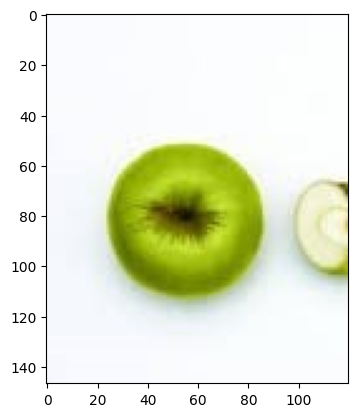

In [9]:
img = mpimg.imread('/content/Fruits Classification/train/Apple/Apple (1).jpeg')
imgplt = plt.imshow(img)
plt.show()

In [10]:
#Load training and testing data

filename = os.listdir('/content/Fruits Classification/train')
print(filename[:10])

filename_test = os.listdir('/content/Fruits Classification/test')
print(filename_test[:10])


['Grape', 'Strawberry', 'Banana', 'Apple', 'Mango']
['Grape', 'Strawberry', 'Banana', 'Apple', 'Mango']


In [11]:
fruit_dict = {
    'Apple' : 0,
    'Banana' : 1,
    'Grape' : 2,
    'Mango' : 3,
    'Strawberry' : 4
}

In [15]:
data = []
fruit_labels = []

for file_name in filename:
  original_path = os.path.join('/content/Fruits Classification/train',file_name)
  # print(original_path)

  for img_file in os.listdir(original_path):
    # print(original_path + "/" + img_file)
    image = Image.open(original_path + "/" + img_file)
    image = image.resize((100,100))
    image = image.convert('RGB')
    image = np.array(image)

    data.append(image)

    fruit_labels.append(fruit_dict[file_name])

for file_name in filename_test:
  original_path_te = os.path.join('/content/Fruits Classification/test',file_name)

  for img_file in os.listdir(original_path_te):
    image = Image.open(original_path_te + "/" + img_file)
    image = image.resize((100,100))
    image = image.convert('RGB')
    image = np.array(image)

    data.append(image)

    fruit_labels.append(fruit_dict[file_name])

In [16]:
type(data)

list

In [17]:
type(fruit_labels)

list

In [18]:
len(fruit_labels)

9800

In [19]:
X = np.array(data)
y = np.array(fruit_labels)

In [20]:
type(data[0])

numpy.ndarray

In [21]:
len(X)

9800

In [22]:
#Train and testing
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [23]:
X_train.shape

(7840, 100, 100, 3)

In [25]:
y_train.shape

(7840,)

In [26]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [27]:
import tensorflow as tf
from tensorflow import keras

In [28]:
#CNN MODEL

model = keras.Sequential([
    keras.layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(100,100,3)),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    keras.layers.Flatten(),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(32,activation='relu'),
    keras.layers.Dropout(0.5),
    keras.layers.Dense(5,activation='softmax')
])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [29]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [30]:
model.fit(X_train_scaled,y_train,epochs=10)

Epoch 1/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 155s 615ms/step - accuracy: 0.2685 - loss: 1.5664
Epoch 2/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 197s 599ms/step - accuracy: 0.4261 - loss: 1.3102
Epoch 3/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 203s 602ms/step - accuracy: 0.5048 - loss: 1.1790
Epoch 4/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 199s 590ms/step - accuracy: 0.5427 - loss: 1.1123
Epoch 5/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 200s 581ms/step - accuracy: 0.5433 - loss: 1.0941
Epoch 6/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 209s 609ms/step - accuracy: 0.5847 - loss: 1.0176
Epoch 7/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 195s 581ms/step - accuracy: 0.5972 - loss: 0.9939
Epoch 8/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 202s 581ms/step - accuracy: 0.6260 - loss: 0.9442
Epoch 9/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 200s 571ms/step - accuracy: 0.6555 - loss: 0.8923
Epoch 10/10
245/245 ━━━━━━━━━━━━━━━━━━━━ 151s 610ms/step - accuracy: 0.6655 - loss: 0.8498


In [31]:
score, acc = model.evaluate(X_test_scaled, y_test)
print('Test Loss =', score)
print('Test Accuracy =', acc)

62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - accuracy: 0.6791 - loss: 0.8617
Test Loss = 0.8762791156768799
Test Accuracy = 0.672448992729187


Path of the image to be predicted: /content/Fruits Classification/train/Strawberry/Strawberry (1).jpeg


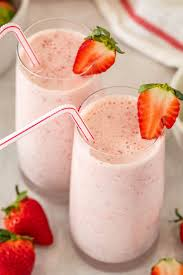

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[0.24532658 0.25229022 0.3404571  0.14307977 0.01884638]]
2
The image represents a Grape


In [37]:
input_image_path = input('Path of the image to be predicted: ')

input_image = cv2.imread(input_image_path)

cv2_imshow(input_image)

input_image_resize = cv2.resize(input_image, (100,100))

input_image_scaled = input_image_resize/255

image_reshaped = np.reshape(input_image_scaled, [1,100,100,3])

input_prediction = model.predict(image_reshaped)

print(input_prediction)

input_pred_label = np.argmax(input_prediction)

print(input_pred_label)

if input_pred_label == 0:
  print('The image represents a Apple')

elif input_pred_label == 1:
  print('The image represents a Banana')

elif input_pred_label == 2:
  print('The image represents a Grape')

elif input_pred_label == 3:
  print('The image represents a Mango')

else:
  print('The image represents a Strawberry')

